In [26]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
import sys
print(sys.executable)

### Get MNIST data set

# Using scikit-learn (OpenML)
from sklearn.datasets import fetch_openml
X, y = fetch_openml("mnist_784",version=1,return_X_y=True,as_frame=False)
print(X.shape)  # (70000, 784)
print(y.shape)  # (70000,)


# Using TensorFlow / Keras
from tensorflow.keras.datasets import mnist
(X_train, y_train), (X_test, y_test) = mnist.load_data()
print(X_train.shape)  # (60000, 28, 28)
print(X_test.shape)   # (10000, 28, 28)


# Using PyTorch
import torch
import torchvision
from torchvision import datasets
mnist = datasets.MNIST(root="./data",train=True,download=True)
print(len(mnist))
print(torch.__version__)
print(torchvision.__version__)


print("Setup complete")

c:\Users\iyke\anaconda3\python.exe
(70000, 784)
(70000,)
(60000, 28, 28)
(10000, 28, 28)
60000
2.12.1+cpu
0.27.1+cpu
Setup complete


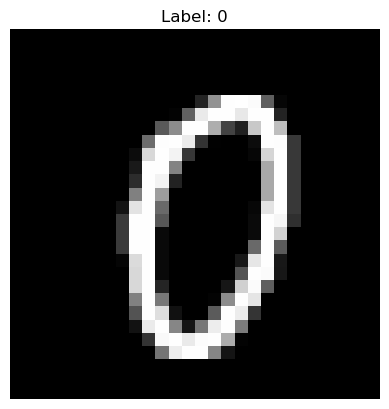

In [27]:
# Using scikit-learn (OpenML)
image = X[1000].reshape(28, 28)

plt.imshow(image, cmap="gray")
plt.title(f"Label: {y[1000]}")
plt.axis("off")
plt.show()

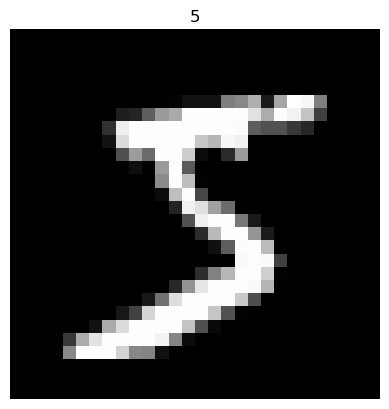

In [28]:
# Using TensorFlow / Keras
plt.imshow(X_train[0], cmap="gray")
plt.title(y_train[0])
plt.axis("off")
plt.show()

In [29]:
# Using PyTorch
image, label = mnist[34]
print(label)
#image.show() # loads image into a folder

0


# <u>Digit classification</u>


**Goal:Classify handwritten digits ranging from 0 to 9 $\Rightarrow g=$ 10 class classification** 

<div style="display: flex; justify-content: center; gap: 10px;">
  <img src="pics/1.png" width="500"/>
</div>

Each data point/image has 28 $\times$ 28 pixels so 784 pixels in total. Each pixel value lies between 0 and 255 with 0 being a fully black pixel and 255 a fully white pixel.

<div style="display: flex; justify-content: center; gap: 10px;">
  <img src="pics/2.png" width="500"/>
</div>


In [30]:
X, y = fetch_openml("mnist_784",version=1,return_X_y=True,as_frame=False)

X = X / 255.0

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=1342)

clf = MLPClassifier(hidden_layer_sizes=(100,),activation="relu",max_iter=20,random_state=1342)

clf.fit(X_train, y_train)

print("Accuracy:", clf.score(X_test, y_test))

Accuracy: 0.9759285714285715


c:\Users\iyke\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(
